In [692]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [693]:
salary = pd.read_csv('Salaries.csv')
salary.head()

C:\ProgramData\Anaconda3\lib\site-packages\IPython\core\interactiveshell.py:3165: DtypeWarning: Columns (3,4,5,6,12) have mixed types.Specify dtype option on import or set low_memory=False.
  has_raised = await self.run_ast_nodes(code_ast.body, cell_name,


,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPay,TotalPayBenefits,Year,Notes,Agency,Status
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,567595.43,2011,NaN,San Francisco,NaN
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,538909.28,2011,NaN,San Francisco,NaN
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,335279.91,2011,NaN,San Francisco,NaN
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,332343.61,2011,NaN,San Francisco,NaN
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,326373.19,2011,NaN,San Francisco,NaN


In [694]:
salary = salary[['Id', 'EmployeeName', 'JobTitle', 'BasePay', 'OvertimePay', 'OtherPay', 'Benefits', 'TotalPayBenefits', 'Year', 'Notes', 'Agency', 'Status', 'TotalPay']]
salary.head()

,Id,EmployeeName,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPayBenefits,Year,Notes,Agency,Status,TotalPay
0,1,NATHANIEL FORD,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,2011,NaN,San Francisco,NaN,567595.43
1,2,GARY JIMENEZ,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,2011,NaN,San Francisco,NaN,538909.28
2,3,ALBERT PARDINI,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,2011,NaN,San Francisco,NaN,335279.91
3,4,CHRISTOPHER CHONG,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,2011,NaN,San Francisco,NaN,332343.61
4,5,PATRICK GARDNER,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,2011,NaN,San Francisco,NaN,326373.19


## Finding NaN values in the Dataset

In [696]:
#drop the columns with high number of NaN values, along with Id and Employee Name
salary.drop(['Id', 'EmployeeName', 'Notes', 'Agency'], inplace=True, axis=1)
salary.head()

,JobTitle,BasePay,OvertimePay,OtherPay,Benefits,TotalPayBenefits,Year,Status,TotalPay
0,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,167411.18,0.0,400184.25,NaN,567595.43,2011,NaN,567595.43
1,CAPTAIN III (POLICE DEPARTMENT),155966.02,245131.88,137811.38,NaN,538909.28,2011,NaN,538909.28
2,CAPTAIN III (POLICE DEPARTMENT),212739.13,106088.18,16452.6,NaN,335279.91,2011,NaN,335279.91
3,WIRE ROPE CABLE MAINTENANCE MECHANIC,77916.0,56120.71,198306.9,NaN,332343.61,2011,NaN,332343.61
4,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",134401.6,9737.0,182234.59,NaN,326373.19,2011,NaN,326373.19


## Replace NaN values in Numerical Variables

In [697]:
#to create a function to impute NaN values
def impute_nan(salary, variable, median):
    salary[variable + '_median'] = salary[variable].fillna(median)

BasePay_median = salary.BasePay.median
impute_nan(salary, 'BasePay', BasePay_median)

In [698]:
salary.drop(['BasePay'], axis=1, inplace=True)

In [699]:
salary['Benefits']=np.where(salary['Benefits'].isnull(), 0, salary['Benefits'])

In [700]:
salary.isnull().sum()

JobTitle                 0
OvertimePay              0
OtherPay                 0
Benefits                 0
TotalPayBenefits         0
Year                     0
Status              110535
TotalPay                 0
BasePay_median           0
dtype: int64

## Handle Categorical Variables

In [701]:
salary['Status']=np.where(salary['Status'].isnull(), 'Undecided', salary['Status'])

In [702]:
salary = salary[['JobTitle', 'OvertimePay', 'OtherPay', 'TotalPayBenefits', 'Year', 'BasePay_median', 'TotalPay', 'Benefits', 'Status']]
salary.head(84507)

,JobTitle,OvertimePay,OtherPay,TotalPayBenefits,Year,BasePay_median,TotalPay,Benefits,Status
0,GENERAL MANAGER-METROPOLITAN TRANSIT AUTHORITY,0.0,400184.25,567595.43,2011,167411.18,567595.43,0,Undecided
1,CAPTAIN III (POLICE DEPARTMENT),245131.88,137811.38,538909.28,2011,155966.02,538909.28,0,Undecided
2,CAPTAIN III (POLICE DEPARTMENT),106088.18,16452.6,335279.91,2011,212739.13,335279.91,0,Undecided
3,WIRE ROPE CABLE MAINTENANCE MECHANIC,56120.71,198306.9,332343.61,2011,77916.0,332343.61,0,Undecided
4,"DEPUTY CHIEF OF DEPARTMENT,(FIRE DEPARTMENT)",9737.0,182234.59,326373.19,2011,134401.6,326373.19,0,Undecided
...,...,...,...,...,...,...,...,...,...
84502,Transit Operator,23245.03,4047.02,131282.32,2013,68773.06,96065.11,35217.21,Undecided
84503,Police Officer,2118.28,4410.08,131278.66,2013,92259.09,98787.45,32491.21,Undecided
84504,Airport Property Specialist 1,0.0,0.0,131273.75,2013,97261.84,97261.84,34011.91,Undecided
84505,Steamfitter,0.0,3913.05,131267.60,2013,94675.35,98588.40,32679.2,Undecided


In [703]:
salary.isnull().sum()

JobTitle            0
OvertimePay         0
OtherPay            0
TotalPayBenefits    0
Year                0
BasePay_median      0
TotalPay            0
Benefits            0
Status              0
dtype: int64

In [704]:
salary["BasePay_median"].replace({"Not Provided": 0}, inplace=True)
salary["OvertimePay"].replace({"Not Provided": 0}, inplace=True)
salary["OtherPay"].replace({"Not Provided": 0}, inplace=True)
salary["Benefits"].replace({"Not Provided": 0}, inplace=True)

## Plot to check relations of correlation between numerical variables

In [705]:
salary["OvertimePay"] = pd.to_numeric(salary["OvertimePay"])
salary["OtherPay"] = pd.to_numeric(salary["OtherPay"])
salary["Benefits"] = pd.to_numeric(salary["Benefits"])
salary["BasePay_median"] = pd.to_numeric(salary["BasePay_median"])

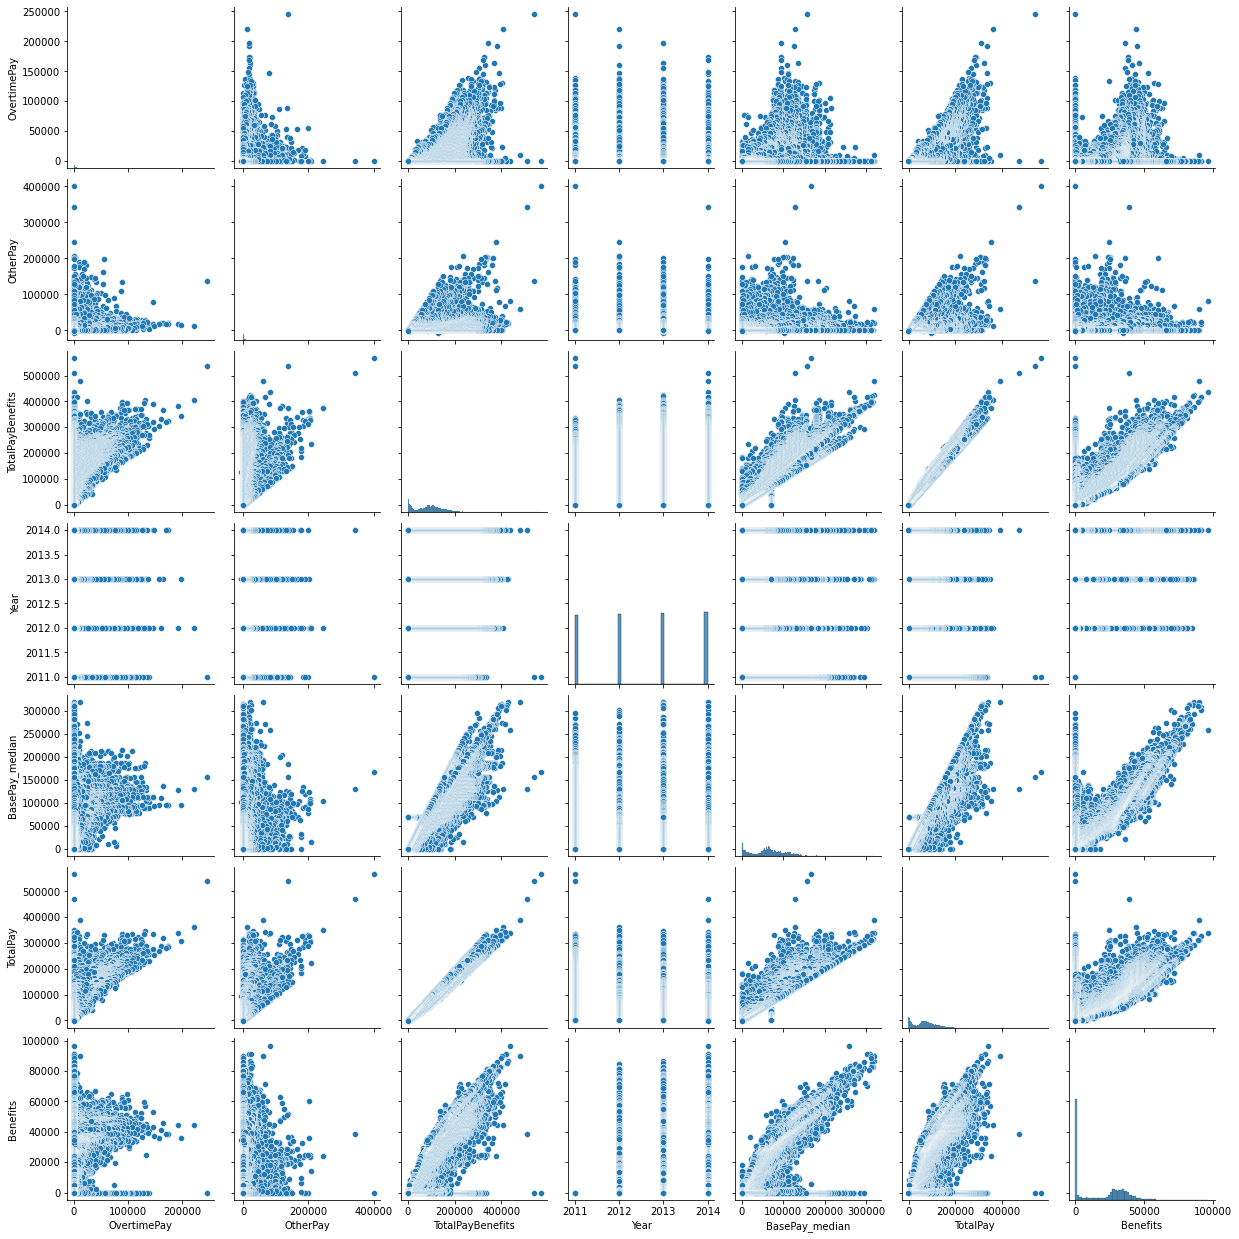

In [706]:
sns.pairplot(salary)

## Plot to check distribution of categorical variables

In [707]:
salary.dtypes

JobTitle             object
OvertimePay         float64
OtherPay            float64
TotalPayBenefits    float64
Year                  int64
BasePay_median      float64
TotalPay            float64
Benefits            float64
Status               object
dtype: object

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='JobTitle', ylabel='count'>

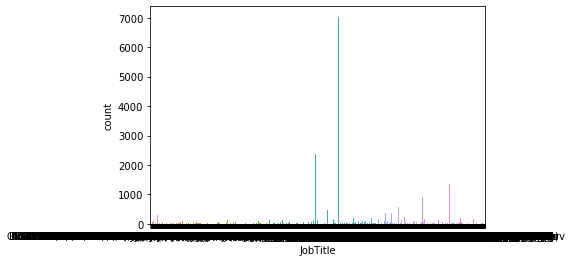

In [708]:
sns.countplot('JobTitle', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variable as a keyword arg: x. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Status', ylabel='count'>

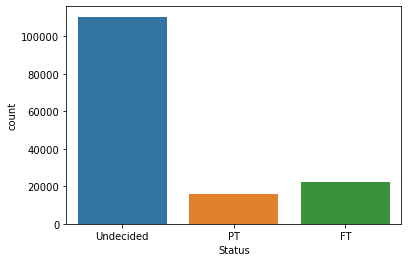

In [709]:
sns.countplot('Status', data=salary)

## Plot to check the relation of the numerical variable with the dependent variable (also check for outliers)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='OvertimePay', ylabel='Status'>

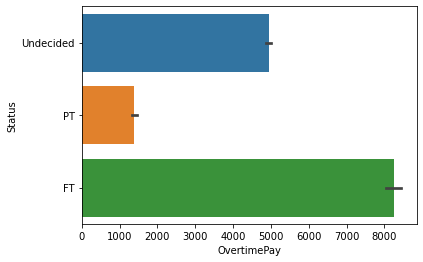

In [710]:
sns.barplot('OvertimePay', 'Status', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='OtherPay', ylabel='Status'>

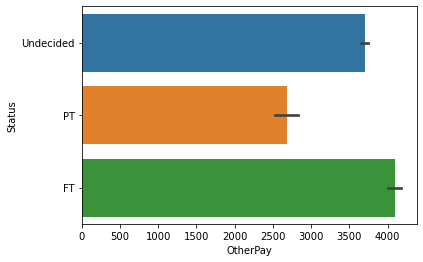

In [711]:
sns.barplot('OtherPay', 'Status', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='TotalPayBenefits', ylabel='Status'>

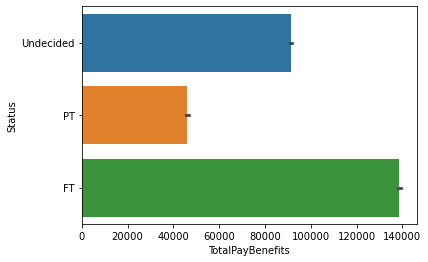

In [712]:
sns.barplot('TotalPayBenefits', 'Status', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='BasePay_median', ylabel='Status'>

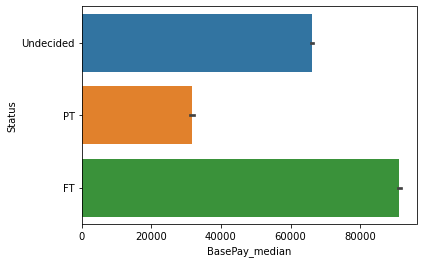

In [714]:
sns.barplot('BasePay_median', 'Status', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='TotalPay', ylabel='Status'>

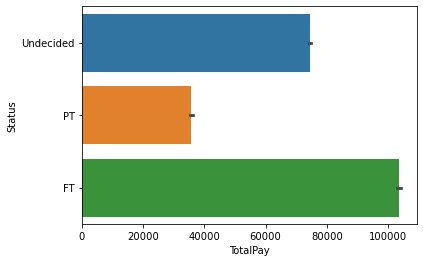

In [715]:
sns.barplot('TotalPay', 'Status', data=salary)

C:\ProgramData\Anaconda3\lib\site-packages\seaborn\_decorators.py:36: FutureWarning: Pass the following variables as keyword args: x, y. From version 0.12, the only valid positional argument will be `data`, and passing other arguments without an explicit keyword will result in an error or misinterpretation.
  warnings.warn(


<AxesSubplot:xlabel='Benefits', ylabel='Status'>

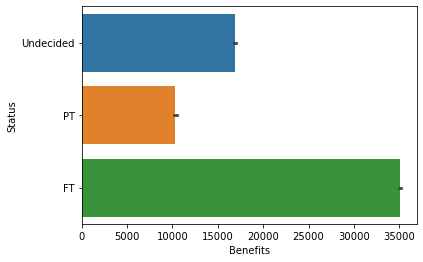

In [716]:
sns.barplot('Benefits', 'Status', data=salary)

## Perform Count Frequency Encoding

In [717]:
#to find the number of times a category is present in the variable
salary_JobTitle = salary.JobTitle.value_counts().to_dict()
salary_JobTitle

{'Transit Operator': 7036,
 'Special Nurse': 4389,
 'Registered Nurse': 3736,
 'Public Svc Aide-Public Works': 2518,
 'Police Officer 3': 2421,
 'Custodian': 2418,
 'TRANSIT OPERATOR': 2388,
 'Firefighter': 2359,
 'Recreation Leader': 1971,
 'Patient Care Assistant': 1945,
 'Deputy Sheriff': 1933,
 'Police Officer': 1476,
 'SPECIAL NURSE': 1402,
 'Public Service Trainee': 1328,
 'REGISTERED NURSE': 1219,
 'Police Officer 2': 1141,
 'Attorney (Civil/Criminal)': 1126,
 'Porter': 1095,
 'Sergeant 3': 1047,
 'General Laborer': 1033,
 'EMT/Paramedic/Firefighter': 918,
 'Gardener': 894,
 'Parking Control Officer': 868,
 'Senior Clerk': 840,
 'Library Page': 799,
 'CUSTODIAN': 796,
 'FIREFIGHTER': 794,
 'POLICE OFFICER III': 779,
 'Clerk': 764,
 'Eligibility Worker': 760,
 'Senior Clerk Typist': 745,
 'Licensed Vocational Nurse': 707,
 'RECREATION LEADER': 692,
 'DEPUTY SHERIFF': 685,
 'Nurse Practitioner': 674,
 'Stationary Engineer': 660,
 'Electrical Transit System Mech': 631,
 'PS Aide to

In [718]:
#to find the number of times a category is present in the variable
salary_Status = salary.Status.value_counts().to_dict()
salary_Status

{'Undecided': 110535, 'FT': 22334, 'PT': 15785}

In [719]:
salary.JobTitle = salary.JobTitle.map(salary_JobTitle)
salary.Status = salary.Status.map(salary_Status)

In [724]:
salary.head()

,JobTitle,OvertimePay,OtherPay,TotalPayBenefits,Year,BasePay_median,TotalPay,Benefits,Status
0,2,0.00,400184.25,567595.43,2011,167411.18,567595.43,0.0,110535
1,37,245131.88,137811.38,538909.28,2011,155966.02,538909.28,0.0,110535
2,37,106088.18,16452.60,335279.91,2011,212739.13,335279.91,0.0,110535
3,8,56120.71,198306.90,332343.61,2011,77916.00,332343.61,0.0,110535
4,3,9737.00,182234.59,326373.19,2011,134401.60,326373.19,0.0,110535


## TRAIN TEST SPLIT

In [725]:
X = salary.iloc[:,:-1]
y = salary.iloc[:,-1]

In [726]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

## Use Robust Scaler because of presence of Outliers

In [728]:
from sklearn.preprocessing import RobustScaler
robust = RobustScaler().fit(X_train, y_train)
robust

RobustScaler()

## Use Random Forest Classifier

In [729]:
#Implement Random Forest classifier
from sklearn.ensemble import RandomForestClassifier
classifier=RandomForestClassifier()
classifier.fit(X_train, y_train)

RandomForestClassifier()

In [730]:
#prediction of test data
y_pred = classifier.predict(X_test)

In [731]:
#check accuracy of predicted output values with actual output values
from sklearn.metrics import accuracy_score
score = accuracy_score(y_test, y_pred)
score

0.9925107069982286

In [734]:
from sklearn.metrics import confusion_matrix
accuracy = confusion_matrix(y_test, y_pred)
accuracy

array([[ 4593,   190,     0],
       [  144,  6587,     0],
       [    0,     0, 33083]], dtype=int64)

## Evaluation

In [735]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       15785       0.97      0.96      0.96      4783
       22334       0.97      0.98      0.98      6731
      110535       1.00      1.00      1.00     33083

    accuracy                           0.99     44597
   macro avg       0.98      0.98      0.98     44597
weighted avg       0.99      0.99      0.99     44597

